
AFM CURVE ALIGNER - DETECCION MEJORADA
Carpeta: D:\ORDENADOR AFM1\01.ANÁLISIS COMPARATIVA EXPERIMENTOS\ANÁLISIS CURVAS PYTHON\Estacionaria-exponencial
k cantiléver: 3.05 N/m
Sensibilidad: 78 nm/V
Fracción línea base: 0.35
Puntos persistencia: 21
Ventana detección: 15
Suavizado visual: True
Ventana suavizado visual: 9

Curvas encontradas: 3
  - 77-Mediciones-HeliosExp-29-10-2024_0003_Normal force.fz.cur
  - 77-Mediciones-HeliosExp-29-10-2024_0136_Normal force.fz.cur
  - 78-Helios-Estc-HR-22-11-2024_0001_Normal force.fz.cur

Procesando C001: 77-Mediciones-HeliosExp-29-10-2024_0003_Normal force.fz.cur
  Estado: OK
  Pendiente aparente: 2.324 N/m
  R²: 0.9999
  F máx original: 116.7 nN
  F mín original: -6.89 nN
  Z alineamiento crudo: 80.2 nm


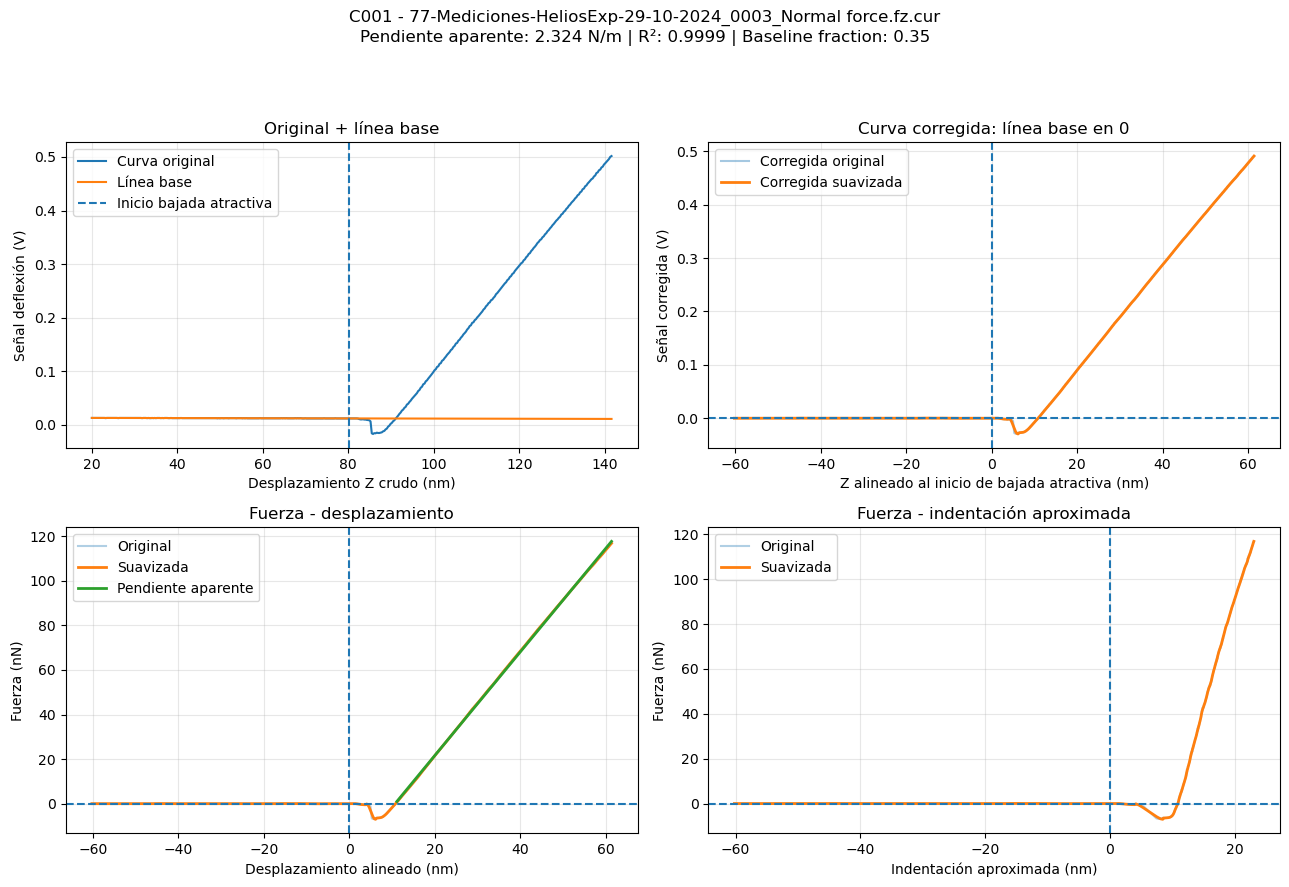


Procesando C002: 77-Mediciones-HeliosExp-29-10-2024_0136_Normal force.fz.cur
  Estado: OK
  Pendiente aparente: 2.692 N/m
  R²: 0.9967
  F máx original: 116.8 nN
  F mín original: -11.64 nN
  Z alineamiento crudo: 59.99 nm


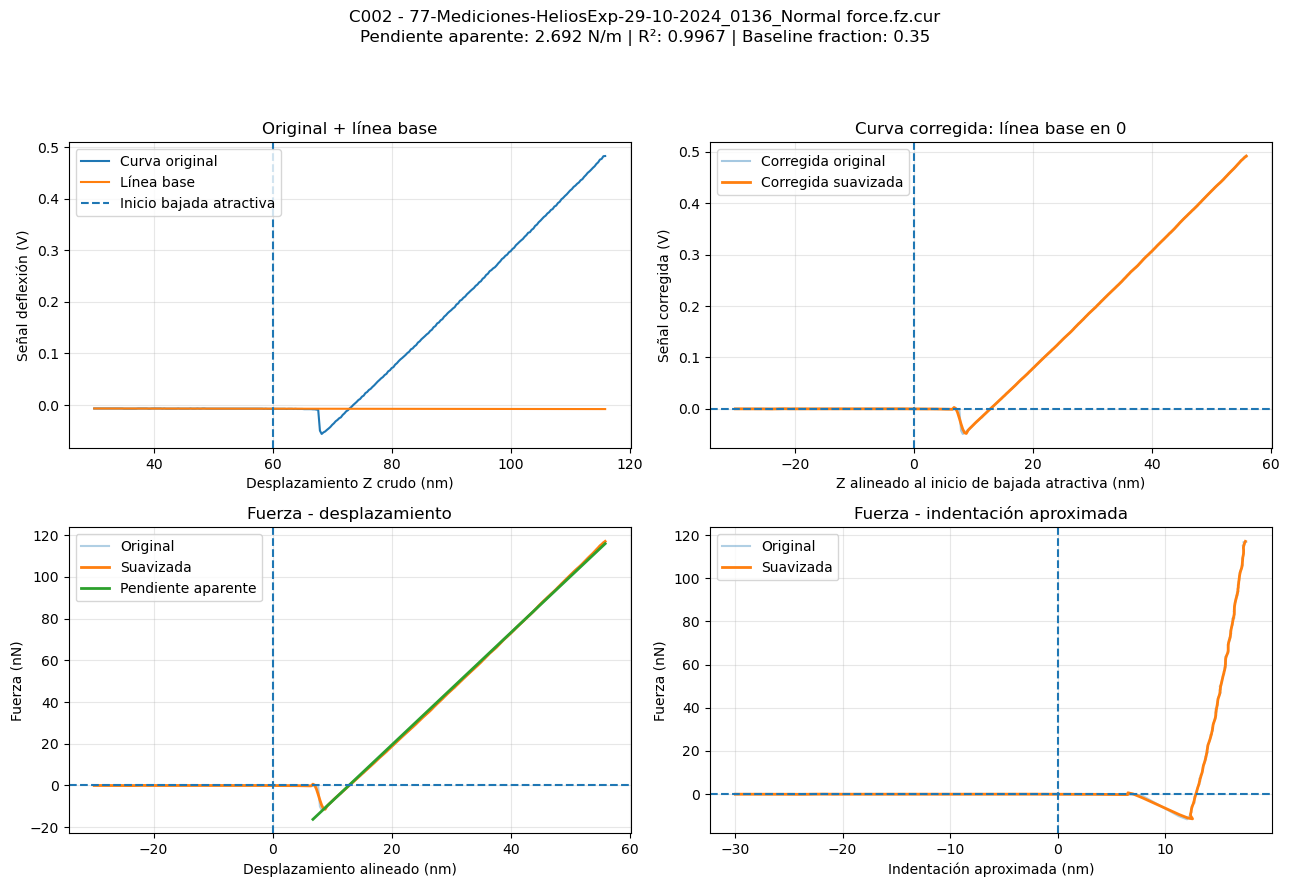


Procesando C003: 78-Helios-Estc-HR-22-11-2024_0001_Normal force.fz.cur
  Estado: OK
  Pendiente aparente: 2.532 N/m
  R²: 0.9825
  F máx original: 237.6 nN
  F mín original: -6.15 nN
  Z alineamiento crudo: 85.97 nm


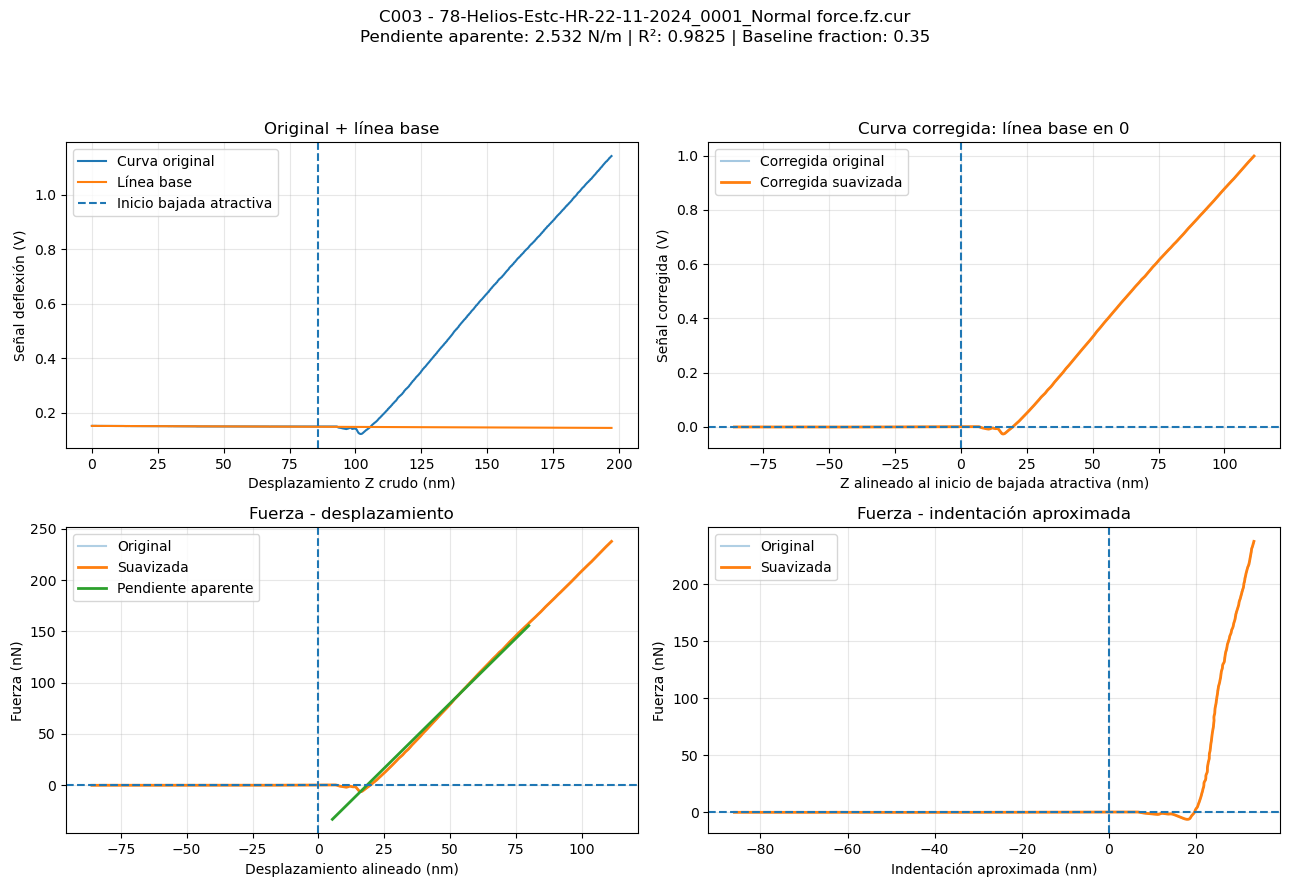


RESUMEN
C001 | OK | k aparente = 2.324 N/m | R² = 0.9999 | Fmin = -6.89 nN | Fmax = 116.7 nN | Zalign = 80.2 nm | 77-Mediciones-HeliosExp-29-10-2024_0003_Normal force.fz.cur
C002 | OK | k aparente = 2.692 N/m | R² = 0.9967 | Fmin = -11.64 nN | Fmax = 116.8 nN | Zalign = 59.99 nm | 77-Mediciones-HeliosExp-29-10-2024_0136_Normal force.fz.cur
C003 | OK | k aparente = 2.532 N/m | R² = 0.9825 | Fmin = -6.15 nN | Fmax = 237.6 nN | Zalign = 85.97 nm | 78-Helios-Estc-HR-22-11-2024_0001_Normal force.fz.cur



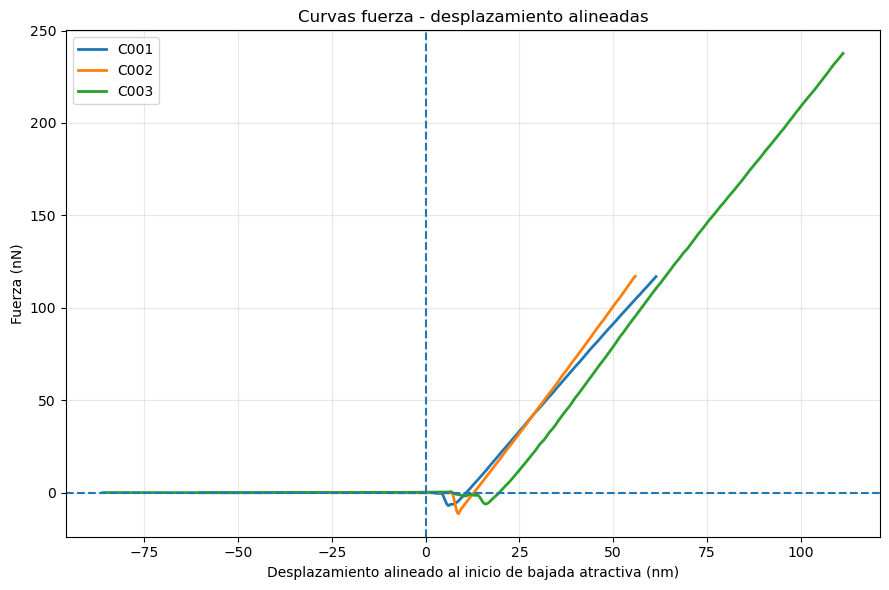

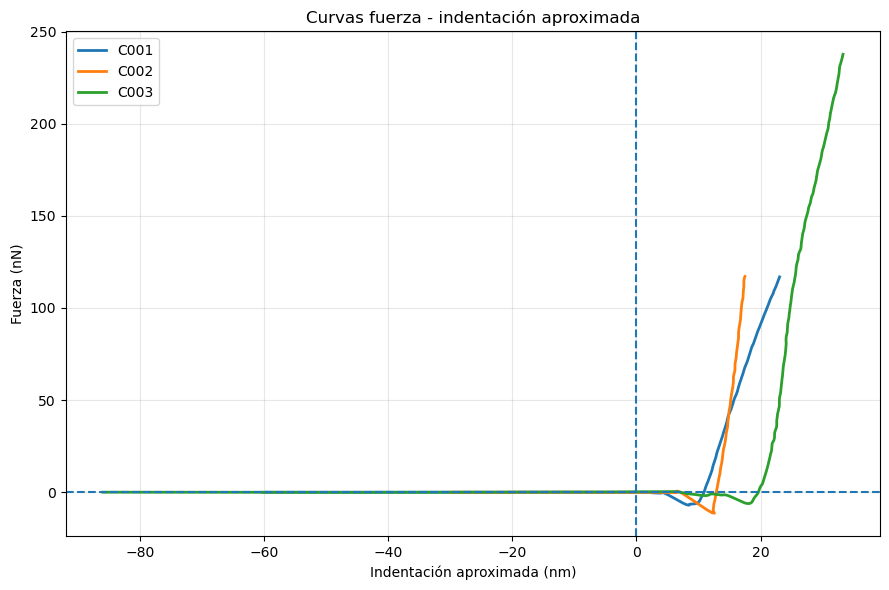

¿Quieres guardar el Excel con los datos procesados? [s/n]:  s



Excel guardado correctamente:
D:\ORDENADOR AFM1\01.ANÁLISIS COMPARATIVA EXPERIMENTOS\ANÁLISIS CURVAS PYTHON\Estacionaria-exponencial\AFM_curvas_alineadas_para_Origin.xlsx

Proceso finalizado.


In [25]:
# ============================================================
# AFM CURVE ALIGNER - VERSION SIMPLE CORREGIDA + DETECCION MEJORADA
# ============================================================
#
# Objetivo:
#   - Leer todas las curvas .cur de una carpeta
#   - Corregir línea base inicial de aproximación
#   - Poner la línea base inicial en F = 0
#   - Detectar el inicio real de la bajada atractiva
#   - Alinear todas las curvas en X = 0 en ese inicio de bajada
#   - NO forzar ese punto a F = 0
#   - Convertir señal V a fuerza nN
#   - Calcular indentación aproximada
#   - Suavizar curvas solo para representación
#   - Mostrar gráficas individuales y conjuntas
#   - Preguntar si guardar Excel
#   - Guardar Excel en la misma carpeta
#
# Requisitos:
#   pip install numpy pandas matplotlib scipy openpyxl
#
# ============================================================


# ============================================================
# 1. IMPORTAR LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Optional
from scipy.stats import linregress
from scipy.signal import savgol_filter


# ============================================================
# 2. ENTRADA DE DATOS DEL USUARIO
# ============================================================
# MODIFICA SOLO ESTA PARTE
# ============================================================

# Carpeta donde están tus curvas .cur
input_folder = r"D:\ORDENADOR AFM1\01.ANÁLISIS COMPARATIVA EXPERIMENTOS\ANÁLISIS CURVAS PYTHON\Estacionaria-exponencial"

# Constante elástica del cantiléver en N/m
k_cantilever_N_per_m = 3.05

# Sensibilidad de deflexión sobre superficie rígida, en nm/V
deflection_sensitivity_nm_per_V = 78

# Extensión de los archivos
file_extension = ".cur"

# ------------------------------------------------------------
# Línea base
# ------------------------------------------------------------
# Fracción inicial de la curva usada para estimar la línea base.
#
# Recomendación:
#   0.10 si la atracción aparece pronto
#   0.15 valor recomendado para empezar
#   0.20 si la línea base inicial es larga y estable
#
baseline_fraction = 0.35

# ------------------------------------------------------------
# Detección del inicio real de la bajada atractiva
# ------------------------------------------------------------
# Estos son los únicos parámetros de detección que quizá tengas
# que ajustar si el punto sigue saliendo antes o después.

# Cuántos puntos consecutivos deben mostrar bajada real.
# Si detecta demasiado pronto, sube a 9 o 11.
# Si detecta demasiado tarde, baja a 5.
persistence_points = 21

# Suavizado interno para detectar la bajada.
# Si detecta demasiado pronto, sube a 11.
# Si detecta demasiado tarde, baja a 7.
detection_smoothing_window = 15

# ------------------------------------------------------------
# Suavizado para visualización
# ------------------------------------------------------------
# El suavizado NO reemplaza los datos originales.
# Solo se usa para mostrar/exportar una curva más limpia.
smoothing_enabled = True

# Ventana de suavizado en puntos.
# Debe ser impar: 5, 7, 9, 11, 15...
smoothing_window_points = 9

# Orden del polinomio Savitzky-Golay.
# 2 suele ser adecuado.
smoothing_polyorder = 2

# Usar curvas suavizadas en la gráfica conjunta
use_smoothed_for_overlay_plot = True

# Mostrar gráficas individuales de control
show_individual_plots = True

# Mostrar gráfica conjunta final
show_overlay_plots = True


# ============================================================
# 3. CONFIGURACIÓN INTERNA
# ============================================================

@dataclass
class Config:
    input_folder: str
    file_extension: str = ".cur"

    k_cantilever_N_per_m: float = 38.0
    deflection_sensitivity_nm_per_V: float = 45.0

    column_z_nm: int = 0
    column_deflection_V: int = 1

    header_end_marker: str = "[Header end]"

    baseline_fraction: float = 0.15
    min_baseline_points: int = 40

    # Detección del inicio real de la bajada atractiva
    persistence_points: int = 7
    detection_smoothing_window: int = 9

    # Ajuste visual de pendiente aparente en F vs desplazamiento
    fit_start_nm: float = 5.0
    fit_end_nm: float = 80.0

    # Suavizado
    smoothing_enabled: bool = True
    smoothing_window_points: int = 9
    smoothing_polyorder: int = 2
    use_smoothed_for_overlay_plot: bool = True

    show_individual_plots: bool = True
    show_overlay_plots: bool = True


config = Config(
    input_folder=input_folder,
    file_extension=file_extension,
    k_cantilever_N_per_m=k_cantilever_N_per_m,
    deflection_sensitivity_nm_per_V=deflection_sensitivity_nm_per_V,
    baseline_fraction=baseline_fraction,
    persistence_points=persistence_points,
    detection_smoothing_window=detection_smoothing_window,
    smoothing_enabled=smoothing_enabled,
    smoothing_window_points=smoothing_window_points,
    smoothing_polyorder=smoothing_polyorder,
    use_smoothed_for_overlay_plot=use_smoothed_for_overlay_plot,
    show_individual_plots=show_individual_plots,
    show_overlay_plots=show_overlay_plots,
)


# ============================================================
# 4. ESTRUCTURAS DE RESULTADOS
# ============================================================

@dataclass
class CurveResult:
    curve_id: str
    file_name: str
    file_path: str

    alignment_index: int
    alignment_z_raw_nm: float

    baseline_fraction_used: float
    baseline_slope_V_per_nm: float
    baseline_intercept_V: float
    baseline_noise_V: float

    max_force_nN_original: float
    max_force_nN_smooth: float
    min_force_nN_original: float
    min_force_nN_smooth: float

    max_indentation_nm_original: float
    max_indentation_nm_smooth: float

    apparent_stiffness_N_per_m: Optional[float]
    fit_r2: Optional[float]

    status: str
    warning: str


@dataclass
class ProcessedCurve:
    result: CurveResult

    z_raw_nm: np.ndarray
    signal_raw_V: np.ndarray

    baseline_V: np.ndarray
    signal_corrected_V: np.ndarray

    z_aligned_nm: np.ndarray

    force_nN: np.ndarray
    force_nN_smooth: np.ndarray

    deflection_nm: np.ndarray
    deflection_nm_smooth: np.ndarray

    indentation_nm: np.ndarray
    indentation_nm_smooth: np.ndarray

    fit_x_nm: Optional[np.ndarray]
    fit_y_pred_nN: Optional[np.ndarray]


# ============================================================
# 5. FUNCIONES AUXILIARES
# ============================================================

def robust_sigma(x):
    """
    Estimador robusto del ruido usando MAD.
    """
    x = np.asarray(x)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return 0.0

    median = np.median(x)
    mad = np.median(np.abs(x - median))
    sigma = 1.4826 * mad

    if sigma <= 0 or not np.isfinite(sigma):
        sigma = np.std(x)

    return float(sigma)


def moving_average(x, window):
    """
    Suavizado simple para detección del inicio atractivo.
    No se usa como curva final.
    """
    x = np.asarray(x, dtype=float)

    if window <= 1:
        return x.copy()

    if window % 2 == 0:
        window += 1

    if len(x) < window:
        return x.copy()

    kernel = np.ones(window) / window

    return np.convolve(x, kernel, mode="same")


def smooth_curve(y, window_points=9, polyorder=2):
    """
    Suavizado Savitzky-Golay para representación visual.
    Mantiene mejor las pendientes que una media móvil simple.
    """
    y = np.asarray(y, dtype=float)

    if len(y) < 5:
        return y.copy()

    window = int(window_points)

    if window < 3:
        return y.copy()

    if window % 2 == 0:
        window += 1

    if window >= len(y):
        window = len(y) - 1

    if window % 2 == 0:
        window -= 1

    if window <= polyorder:
        window = polyorder + 3

    if window % 2 == 0:
        window += 1

    if window >= len(y):
        return y.copy()

    try:
        return savgol_filter(
            y,
            window_length=window,
            polyorder=polyorder,
            mode="interp"
        )
    except Exception:
        return y.copy()


def ask_yes_no(question):
    """
    Pregunta sí/no en consola.
    """
    while True:
        answer = input(question + " [s/n]: ").strip().lower()

        if answer in ["s", "si", "sí", "y", "yes"]:
            return True

        if answer in ["n", "no"]:
            return False

        print("Respuesta no válida. Escribe s o n.")


def safe_name(text):
    """
    Limpia texto para nombres de columnas Excel.
    """
    bad_chars = ['\\', '/', ':', '*', '?', '"', '<', '>', '|', '[', ']']
    text = str(text)

    for ch in bad_chars:
        text = text.replace(ch, "_")

    return text[:80]


def pad_array(arr, length):
    """
    Rellena arrays de distinta longitud con NaN.
    """
    arr = np.asarray(arr)
    out = np.full(length, np.nan)
    out[:len(arr)] = arr
    return out


# ============================================================
# 6. BUSCAR Y LEER ARCHIVOS
# ============================================================

def find_curve_files(cfg):
    """
    Busca todos los archivos con la extensión indicada en la carpeta.
    """
    folder = Path(cfg.input_folder)

    if not folder.exists():
        raise FileNotFoundError(f"No existe la carpeta:\n{folder}")

    if not folder.is_dir():
        raise NotADirectoryError(f"La ruta indicada no es una carpeta:\n{folder}")

    files = sorted(folder.glob(f"*{cfg.file_extension}"))

    return files


def read_curve_file(file_path, cfg):
    """
    Lee archivo .cur.
    Si encuentra '[Header end]', lee desde la línea siguiente.
    Si no, intenta leer todas las líneas numéricas.
    """
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    start_index = 0

    for i, line in enumerate(lines):
        if cfg.header_end_marker in line:
            start_index = i + 1
            break

    data = []

    for line in lines[start_index:]:
        line = line.strip()

        if not line:
            continue

        if line.startswith("["):
            continue

        line = line.replace(";", " ").replace(",", " ")
        parts = line.split()

        try:
            values = [float(p) for p in parts]
        except ValueError:
            continue

        if len(values) > max(cfg.column_z_nm, cfg.column_deflection_V):
            data.append(values)

    if len(data) < 20:
        raise ValueError("No se encontraron suficientes datos numéricos.")

    arr = np.array(data, dtype=float)

    z_nm = arr[:, cfg.column_z_nm]
    signal_V = arr[:, cfg.column_deflection_V]

    mask = np.isfinite(z_nm) & np.isfinite(signal_V)

    z_nm = z_nm[mask]
    signal_V = signal_V[mask]

    if len(z_nm) < 20:
        raise ValueError("Datos insuficientes tras eliminar NaN/inf.")

    return z_nm, signal_V


# ============================================================
# 7. CORRECCIÓN DE LÍNEA BASE
# ============================================================

def correct_baseline(z_nm, signal_V, cfg):
    """
    Ajusta la parte inicial de aproximación como línea base.

    La línea base corregida queda centrada en cero:
        baseline inicial ≈ 0 V
    """
    n = len(z_nm)

    n_base = int(cfg.baseline_fraction * n)
    n_base = max(n_base, cfg.min_baseline_points)
    n_base = min(n_base, n - 5)

    z_base = z_nm[:n_base]
    y_base = signal_V[:n_base]

    slope, intercept, _, _, _ = linregress(z_base, y_base)

    baseline = slope * z_nm + intercept
    corrected = signal_V - baseline

    # Corrección fina: forzar la mediana de la región basal a cero
    baseline_offset = np.median(corrected[:n_base])
    corrected = corrected - baseline_offset
    baseline = baseline + baseline_offset

    noise = robust_sigma(corrected[:n_base])

    return baseline, corrected, slope, intercept, noise, n_base


# ============================================================
# 8. DETECCIÓN DEL INICIO REAL DE LA BAJADA ATRACTIVA
# ============================================================

def find_attraction_onset(corrected_V, noise_V, start_index, cfg):
    """
    Detecta el inicio real de la bajada atractiva.

    Esta versión NO busca simplemente la primera desviación respecto
    a la línea base, porque eso puede detectar ruido demasiado pronto.

    En su lugar:
        1. suaviza ligeramente la señal;
        2. calcula la pendiente local;
        3. busca una pendiente negativa persistente;
        4. coloca el punto de alineamiento al inicio de esa bajada.

    El punto detectado se usa para alinear horizontalmente X = 0.
    No se fuerza a F = 0.
    """

    y = np.asarray(corrected_V, dtype=float)

    # --------------------------------------------------------
    # Suavizado para detección
    # --------------------------------------------------------
    y_smooth = moving_average(y, cfg.detection_smoothing_window)

    # --------------------------------------------------------
    # Estimar ruido de la línea base
    # --------------------------------------------------------
    if noise_V <= 0 or not np.isfinite(noise_V):
        noise_V = robust_sigma(y_smooth[:start_index])

    # --------------------------------------------------------
    # Derivada local
    # --------------------------------------------------------
    dy = np.gradient(y_smooth)

    # Ruido de la derivada estimado en la línea base
    dy_noise = robust_sigma(dy[:start_index])

    if dy_noise <= 0 or not np.isfinite(dy_noise):
        dy_noise = np.std(dy[:start_index])

    # Umbral de pendiente negativa.
    # Más alto en valor absoluto = detecta más tarde, solo bajadas claras.
    slope_threshold = -3.0 * dy_noise

    # También exigimos que la señal baje algo respecto a la línea base.
    amplitude_threshold = -2.0 * noise_V

    persistence = max(5, cfg.persistence_points)

    # --------------------------------------------------------
    # Buscar pendiente negativa persistente
    # --------------------------------------------------------
    for i in range(start_index, len(y_smooth) - persistence):
        slope_segment = dy[i:i + persistence]
        signal_segment = y_smooth[i:i + persistence]

        condition_slope = np.all(slope_segment < slope_threshold)
        condition_amplitude = np.min(signal_segment) < amplitude_threshold

        if condition_slope and condition_amplitude:
            return i

    # --------------------------------------------------------
    # Plan B:
    # buscar una caída acumulada clara en una ventana corta
    # --------------------------------------------------------
    window = max(6, persistence)

    for i in range(start_index, len(y_smooth) - window):
        drop = y_smooth[i + window] - y_smooth[i]

        if drop < -3.0 * noise_V:
            return i

    # --------------------------------------------------------
    # Plan C:
    # si no encuentra nada, usar el punto anterior al mínimo atractivo.
    # --------------------------------------------------------
    min_index = int(np.argmin(y_smooth))

    for i in range(min_index, start_index + 1, -1):
        if dy[i] >= 0:
            return i + 1

    return min_index


# ============================================================
# 9. ALINEAMIENTO, CONVERSIÓN Y SUAVIZADO
# ============================================================

def align_convert_and_smooth(z_nm, corrected_V, alignment_index, cfg):
    """
    Alinea horizontalmente en el inicio de la bajada atractiva.

    Importante:
    - La línea base ya está en F = 0.
    - No se resta corrected_V[alignment_index].
    - Por tanto, la bajada atractiva queda por debajo de 0.
    """

    # --------------------------------------------------------
    # Alineamiento horizontal
    # --------------------------------------------------------
    z_aligned_nm = z_nm - z_nm[alignment_index]

    # Hacer que el avance post-alineamiento sea positivo
    post_z = z_aligned_nm[alignment_index:]

    if len(post_z) > 5 and np.nanmedian(post_z) < 0:
        z_aligned_nm = -z_aligned_nm

    # --------------------------------------------------------
    # Alineamiento vertical
    # --------------------------------------------------------
    # NO forzamos el punto de alineamiento a F=0.
    # Conservamos la línea base corregida.
    signal_aligned_V = corrected_V.copy()

    # Asegurar que la zona repulsiva final sea positiva
    post_signal = signal_aligned_V[alignment_index:]

    if len(post_signal) > 10:
        tail = post_signal[int(0.7 * len(post_signal)):]

        if np.nanmedian(tail) < 0:
            signal_aligned_V = -signal_aligned_V

    # Tras posible inversión de signo, volvemos a centrar la línea base
    n_base_zero = int(cfg.baseline_fraction * len(signal_aligned_V))
    n_base_zero = max(n_base_zero, cfg.min_baseline_points)
    n_base_zero = min(n_base_zero, len(signal_aligned_V) - 5)

    zero_offset = np.median(signal_aligned_V[:n_base_zero])
    signal_aligned_V = signal_aligned_V - zero_offset

    # --------------------------------------------------------
    # Conversión V -> nm -> nN
    # --------------------------------------------------------
    deflection_nm = signal_aligned_V * cfg.deflection_sensitivity_nm_per_V

    # k[N/m] * deflection[nm] = force[nN]
    force_nN = cfg.k_cantilever_N_per_m * deflection_nm

    # --------------------------------------------------------
    # Indentación aproximada
    # --------------------------------------------------------
    # Esta indentación está referida al eje alineado.
    # Para análisis mecánico absoluto habría que detectar el contacto repulsivo real.
    indentation_nm = z_aligned_nm - deflection_nm

    # --------------------------------------------------------
    # Suavizado para representación
    # --------------------------------------------------------
    if cfg.smoothing_enabled:
        force_nN_smooth = smooth_curve(
            force_nN,
            window_points=cfg.smoothing_window_points,
            polyorder=cfg.smoothing_polyorder
        )

        deflection_nm_smooth = force_nN_smooth / cfg.k_cantilever_N_per_m
        indentation_nm_smooth = z_aligned_nm - deflection_nm_smooth

    else:
        force_nN_smooth = force_nN.copy()
        deflection_nm_smooth = deflection_nm.copy()
        indentation_nm_smooth = indentation_nm.copy()

    return (
        z_aligned_nm,
        force_nN,
        force_nN_smooth,
        deflection_nm,
        deflection_nm_smooth,
        indentation_nm,
        indentation_nm_smooth
    )


# ============================================================
# 10. AJUSTE DE PENDIENTE APARENTE
# ============================================================

def fit_apparent_stiffness(z_aligned_nm, force_nN_smooth, cfg):
    """
    Ajusta una pendiente aparente sobre la curva suavizada:
        F vs desplazamiento alineado

    Esta pendiente es útil para comparación visual entre curvas.
    """
    mask = (
        np.isfinite(z_aligned_nm)
        & np.isfinite(force_nN_smooth)
        & (z_aligned_nm >= cfg.fit_start_nm)
        & (z_aligned_nm <= cfg.fit_end_nm)
        & (force_nN_smooth > 0)
    )

    if np.sum(mask) < 10:
        return None, None, None, None

    x = z_aligned_nm[mask]
    y = force_nN_smooth[mask]

    slope, intercept, r_value, _, _ = linregress(x, y)

    y_pred = slope * x + intercept
    r2 = r_value ** 2

    # nN/nm = N/m
    stiffness = slope

    return float(stiffness), float(r2), x, y_pred


# ============================================================
# 11. PROCESAR UNA CURVA
# ============================================================

def process_curve(file_path, curve_id, cfg):
    """
    Procesa una curva individual completa.
    """
    z_raw_nm, signal_raw_V = read_curve_file(file_path, cfg)

    baseline, corrected, b_slope, b_intercept, noise, n_base = correct_baseline(
        z_raw_nm,
        signal_raw_V,
        cfg
    )

    alignment_index = find_attraction_onset(
        corrected,
        noise,
        n_base,
        cfg
    )

    (
        z_aligned_nm,
        force_nN,
        force_nN_smooth,
        deflection_nm,
        deflection_nm_smooth,
        indentation_nm,
        indentation_nm_smooth
    ) = align_convert_and_smooth(
        z_raw_nm,
        corrected,
        alignment_index,
        cfg
    )

    stiffness, r2, fit_x, fit_y_pred = fit_apparent_stiffness(
        z_aligned_nm,
        force_nN_smooth,
        cfg
    )

    warning = ""

    if stiffness is None:
        status = "REVISAR"
        warning = "No se pudo calcular pendiente aparente."
    else:
        status = "OK"

    result = CurveResult(
        curve_id=curve_id,
        file_name=file_path.name,
        file_path=str(file_path),

        alignment_index=int(alignment_index),
        alignment_z_raw_nm=float(z_raw_nm[alignment_index]),

        baseline_fraction_used=float(cfg.baseline_fraction),
        baseline_slope_V_per_nm=float(b_slope),
        baseline_intercept_V=float(b_intercept),
        baseline_noise_V=float(noise),

        max_force_nN_original=float(np.nanmax(force_nN)),
        max_force_nN_smooth=float(np.nanmax(force_nN_smooth)),
        min_force_nN_original=float(np.nanmin(force_nN)),
        min_force_nN_smooth=float(np.nanmin(force_nN_smooth)),

        max_indentation_nm_original=float(np.nanmax(indentation_nm)),
        max_indentation_nm_smooth=float(np.nanmax(indentation_nm_smooth)),

        apparent_stiffness_N_per_m=stiffness,
        fit_r2=r2,

        status=status,
        warning=warning
    )

    curve = ProcessedCurve(
        result=result,

        z_raw_nm=z_raw_nm,
        signal_raw_V=signal_raw_V,

        baseline_V=baseline,
        signal_corrected_V=corrected,

        z_aligned_nm=z_aligned_nm,

        force_nN=force_nN,
        force_nN_smooth=force_nN_smooth,

        deflection_nm=deflection_nm,
        deflection_nm_smooth=deflection_nm_smooth,

        indentation_nm=indentation_nm,
        indentation_nm_smooth=indentation_nm_smooth,

        fit_x_nm=fit_x,
        fit_y_pred_nN=fit_y_pred
    )

    return curve


# ============================================================
# 12. GRÁFICAS INDIVIDUALES
# ============================================================

def plot_individual(curve, cfg):
    """
    Gráfica individual de control.
    """
    r = curve.result

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    # --------------------------------------------------------
    # Original + línea base
    # --------------------------------------------------------
    ax = axes[0, 0]
    ax.plot(curve.z_raw_nm, curve.signal_raw_V, label="Curva original")
    ax.plot(curve.z_raw_nm, curve.baseline_V, label="Línea base")
    ax.axvline(
        r.alignment_z_raw_nm,
        linestyle="--",
        label="Inicio bajada atractiva"
    )
    ax.set_xlabel("Desplazamiento Z crudo (nm)")
    ax.set_ylabel("Señal deflexión (V)")
    ax.set_title("Original + línea base")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # --------------------------------------------------------
    # Señal corregida
    # --------------------------------------------------------
    ax = axes[0, 1]

    signal_corrected_for_plot = curve.signal_corrected_V

    signal_smooth_V = (
        curve.force_nN_smooth
        / cfg.k_cantilever_N_per_m
        / cfg.deflection_sensitivity_nm_per_V
    )

    ax.plot(
        curve.z_aligned_nm,
        signal_corrected_for_plot,
        alpha=0.40,
        label="Corregida original"
    )

    ax.plot(
        curve.z_aligned_nm,
        signal_smooth_V,
        linewidth=2,
        label="Corregida suavizada"
    )

    ax.axvline(0, linestyle="--")
    ax.axhline(0, linestyle="--")
    ax.set_xlabel("Z alineado al inicio de bajada atractiva (nm)")
    ax.set_ylabel("Señal corregida (V)")
    ax.set_title("Curva corregida: línea base en 0")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # --------------------------------------------------------
    # Fuerza vs desplazamiento
    # --------------------------------------------------------
    ax = axes[1, 0]

    ax.plot(
        curve.z_aligned_nm,
        curve.force_nN,
        alpha=0.35,
        label="Original"
    )

    ax.plot(
        curve.z_aligned_nm,
        curve.force_nN_smooth,
        linewidth=2,
        label="Suavizada"
    )

    if curve.fit_x_nm is not None and curve.fit_y_pred_nN is not None:
        ax.plot(
            curve.fit_x_nm,
            curve.fit_y_pred_nN,
            linewidth=2,
            label="Pendiente aparente"
        )

    ax.axvline(0, linestyle="--")
    ax.axhline(0, linestyle="--")
    ax.set_xlabel("Desplazamiento alineado (nm)")
    ax.set_ylabel("Fuerza (nN)")
    ax.set_title("Fuerza - desplazamiento")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # --------------------------------------------------------
    # Fuerza vs indentación
    # --------------------------------------------------------
    ax = axes[1, 1]

    ax.plot(
        curve.indentation_nm,
        curve.force_nN,
        alpha=0.35,
        label="Original"
    )

    ax.plot(
        curve.indentation_nm_smooth,
        curve.force_nN_smooth,
        linewidth=2,
        label="Suavizada"
    )

    ax.axvline(0, linestyle="--")
    ax.axhline(0, linestyle="--")
    ax.set_xlabel("Indentación aproximada (nm)")
    ax.set_ylabel("Fuerza (nN)")
    ax.set_title("Fuerza - indentación aproximada")
    ax.legend()
    ax.grid(True, alpha=0.3)

    stiffness_txt = (
        "NA"
        if r.apparent_stiffness_N_per_m is None
        else f"{r.apparent_stiffness_N_per_m:.4g} N/m"
    )

    r2_txt = "NA" if r.fit_r2 is None else f"{r.fit_r2:.4f}"

    fig.suptitle(
        f"{r.curve_id} - {r.file_name}\n"
        f"Pendiente aparente: {stiffness_txt} | R²: {r2_txt} | "
        f"Baseline fraction: {r.baseline_fraction_used}",
        fontsize=12
    )

    fig.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


# ============================================================
# 13. GRÁFICAS CONJUNTAS
# ============================================================

def plot_overlay(curves, cfg):
    """
    Gráficas conjuntas de todas las curvas.
    """
    # --------------------------------------------------------
    # Fuerza vs desplazamiento alineado
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(9, 6))

    for curve in curves:
        y = (
            curve.force_nN_smooth
            if cfg.use_smoothed_for_overlay_plot
            else curve.force_nN
        )

        ax.plot(
            curve.z_aligned_nm,
            y,
            linewidth=2,
            label=curve.result.curve_id
        )

    ax.axvline(0, linestyle="--")
    ax.axhline(0, linestyle="--")
    ax.set_xlabel("Desplazamiento alineado al inicio de bajada atractiva (nm)")
    ax.set_ylabel("Fuerza (nN)")
    ax.set_title("Curvas fuerza - desplazamiento alineadas")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    if cfg.show_overlay_plots:
        plt.show()
    else:
        plt.close(fig)

    # --------------------------------------------------------
    # Fuerza vs indentación
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(9, 6))

    for curve in curves:
        x = (
            curve.indentation_nm_smooth
            if cfg.use_smoothed_for_overlay_plot
            else curve.indentation_nm
        )

        y = (
            curve.force_nN_smooth
            if cfg.use_smoothed_for_overlay_plot
            else curve.force_nN
        )

        ax.plot(
            x,
            y,
            linewidth=2,
            label=curve.result.curve_id
        )

    ax.axvline(0, linestyle="--")
    ax.axhline(0, linestyle="--")
    ax.set_xlabel("Indentación aproximada (nm)")
    ax.set_ylabel("Fuerza (nN)")
    ax.set_title("Curvas fuerza - indentación aproximada")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    if cfg.show_overlay_plots:
        plt.show()
    else:
        plt.close(fig)


# ============================================================
# 14. EXPORTACIÓN A EXCEL
# ============================================================

def export_excel(curves, cfg):
    """
    Exporta un único Excel en la misma carpeta de las curvas.
    """
    folder = Path(cfg.input_folder)
    output_file = folder / "AFM_curvas_alineadas_para_Origin.xlsx"

    df_summary = pd.DataFrame([asdict(c.result) for c in curves])
    df_config = pd.DataFrame([asdict(cfg)])

    max_len = max(len(c.z_aligned_nm) for c in curves)

    data_z_smooth = {}
    data_z_original = {}
    data_ind_smooth = {}
    data_all = {}

    for curve in curves:
        name = safe_name(Path(curve.result.file_name).stem)
        prefix = f"{curve.result.curve_id}_{name}"

        # Para Origin: F vs desplazamiento suavizada
        data_z_smooth[f"{prefix}_Displacement_nm"] = pad_array(
            curve.z_aligned_nm,
            max_len
        )
        data_z_smooth[f"{prefix}_Force_smooth_nN"] = pad_array(
            curve.force_nN_smooth,
            max_len
        )

        # Para Origin: F vs desplazamiento original
        data_z_original[f"{prefix}_Displacement_nm"] = pad_array(
            curve.z_aligned_nm,
            max_len
        )
        data_z_original[f"{prefix}_Force_original_nN"] = pad_array(
            curve.force_nN,
            max_len
        )

        # Para Origin: F vs indentación suavizada
        data_ind_smooth[f"{prefix}_Indentation_smooth_nm"] = pad_array(
            curve.indentation_nm_smooth,
            max_len
        )
        data_ind_smooth[f"{prefix}_Force_smooth_nN"] = pad_array(
            curve.force_nN_smooth,
            max_len
        )

        # Datos completos
        data_all[f"{prefix}_Z_raw_nm"] = pad_array(
            curve.z_raw_nm,
            max_len
        )
        data_all[f"{prefix}_Signal_raw_V"] = pad_array(
            curve.signal_raw_V,
            max_len
        )
        data_all[f"{prefix}_Baseline_V"] = pad_array(
            curve.baseline_V,
            max_len
        )
        data_all[f"{prefix}_Signal_corrected_V"] = pad_array(
            curve.signal_corrected_V,
            max_len
        )
        data_all[f"{prefix}_Z_aligned_nm"] = pad_array(
            curve.z_aligned_nm,
            max_len
        )
        data_all[f"{prefix}_Deflection_nm"] = pad_array(
            curve.deflection_nm,
            max_len
        )
        data_all[f"{prefix}_Deflection_smooth_nm"] = pad_array(
            curve.deflection_nm_smooth,
            max_len
        )
        data_all[f"{prefix}_Force_original_nN"] = pad_array(
            curve.force_nN,
            max_len
        )
        data_all[f"{prefix}_Force_smooth_nN"] = pad_array(
            curve.force_nN_smooth,
            max_len
        )
        data_all[f"{prefix}_Indentation_original_nm"] = pad_array(
            curve.indentation_nm,
            max_len
        )
        data_all[f"{prefix}_Indentation_smooth_nm"] = pad_array(
            curve.indentation_nm_smooth,
            max_len
        )

    with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
        df_summary.to_excel(writer, sheet_name="Resumen", index=False)
        pd.DataFrame(data_z_smooth).to_excel(
            writer,
            sheet_name="Origin_F_vs_Z_suavizada",
            index=False
        )
        pd.DataFrame(data_z_original).to_excel(
            writer,
            sheet_name="Origin_F_vs_Z_original",
            index=False
        )
        pd.DataFrame(data_ind_smooth).to_excel(
            writer,
            sheet_name="Origin_F_vs_Indent_suav",
            index=False
        )
        pd.DataFrame(data_all).to_excel(
            writer,
            sheet_name="Datos_completos",
            index=False
        )
        df_config.to_excel(
            writer,
            sheet_name="Configuracion",
            index=False
        )

    print("\nExcel guardado correctamente:")
    print(output_file)


# ============================================================
# 15. PROGRAMA PRINCIPAL
# ============================================================

def main():
    print("\n============================================================")
    print("AFM CURVE ALIGNER - DETECCION MEJORADA")
    print("============================================================")
    print(f"Carpeta: {config.input_folder}")
    print(f"k cantiléver: {config.k_cantilever_N_per_m} N/m")
    print(f"Sensibilidad: {config.deflection_sensitivity_nm_per_V} nm/V")
    print(f"Fracción línea base: {config.baseline_fraction}")
    print(f"Puntos persistencia: {config.persistence_points}")
    print(f"Ventana detección: {config.detection_smoothing_window}")
    print(f"Suavizado visual: {config.smoothing_enabled}")
    print(f"Ventana suavizado visual: {config.smoothing_window_points}")
    print("============================================================\n")

    files = find_curve_files(config)

    if len(files) == 0:
        print("No se encontraron curvas en la carpeta indicada.")
        print(f"Extensión buscada: {config.file_extension}")
        return

    print(f"Curvas encontradas: {len(files)}")

    for f in files:
        print(f"  - {f.name}")

    curves = []
    failed = []

    for i, file_path in enumerate(files, start=1):
        curve_id = f"C{i:03d}"

        print(f"\nProcesando {curve_id}: {file_path.name}")

        try:
            curve = process_curve(
                file_path=file_path,
                curve_id=curve_id,
                cfg=config
            )

            curves.append(curve)

            r = curve.result

            stiffness_txt = (
                "NA"
                if r.apparent_stiffness_N_per_m is None
                else f"{r.apparent_stiffness_N_per_m:.4g}"
            )

            r2_txt = "NA" if r.fit_r2 is None else f"{r.fit_r2:.4f}"

            print(f"  Estado: {r.status}")
            print(f"  Pendiente aparente: {stiffness_txt} N/m")
            print(f"  R²: {r2_txt}")
            print(f"  F máx original: {r.max_force_nN_original:.4g} nN")
            print(f"  F mín original: {r.min_force_nN_original:.4g} nN")
            print(f"  Z alineamiento crudo: {r.alignment_z_raw_nm:.4g} nm")

            if r.warning:
                print(f"  Aviso: {r.warning}")

            if config.show_individual_plots:
                plot_individual(curve, config)

        except Exception as e:
            failed.append((file_path.name, str(e)))
            print(f"  ERROR: {e}")

    if len(curves) == 0:
        print("\nNo se pudo procesar ninguna curva.")
        return

    print("\n============================================================")
    print("RESUMEN")
    print("============================================================")

    for curve in curves:
        r = curve.result

        stiffness_txt = (
            "NA"
            if r.apparent_stiffness_N_per_m is None
            else f"{r.apparent_stiffness_N_per_m:.4g}"
        )

        r2_txt = "NA" if r.fit_r2 is None else f"{r.fit_r2:.4f}"

        print(
            f"{r.curve_id} | {r.status} | "
            f"k aparente = {stiffness_txt} N/m | "
            f"R² = {r2_txt} | "
            f"Fmin = {r.min_force_nN_original:.4g} nN | "
            f"Fmax = {r.max_force_nN_original:.4g} nN | "
            f"Zalign = {r.alignment_z_raw_nm:.4g} nm | "
            f"{r.file_name}"
        )

    if failed:
        print("\nArchivos fallidos:")
        for name, error in failed:
            print(f"  - {name}: {error}")

    print("============================================================\n")

    if config.show_overlay_plots:
        plot_overlay(curves, config)

    save = ask_yes_no("¿Quieres guardar el Excel con los datos procesados?")

    if save:
        export_excel(curves, config)
    else:
        print("No se guardó ningún archivo.")

    print("\nProceso finalizado.")


# ============================================================
# 16. EJECUTAR
# ============================================================

if __name__ == "__main__":
    main()